# SuperDense Coding

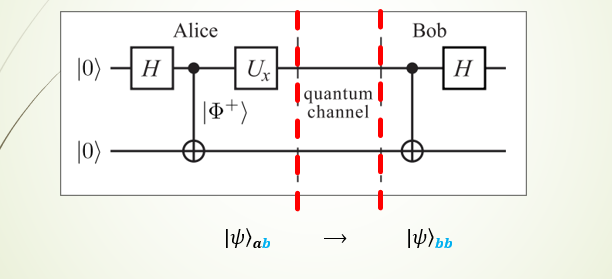

| **Message**             | **Alice Encoding** | **Prepared State** |
|--------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------|
| **00**   | $\mathbb{I}$ | $|\Phi^+⟩ $
| **01**     | $X$ |   $|\Phi^-⟩ $
| **10**      | $Z$ |  $|\Psi^+⟩ $
| **11**     | $ZX$ |  $|\Psi^-⟩ $  


This encoding allows Alice to manipulate her half of the entangled state to encode the desired message efficiently before sending her qubit to Bob.

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *
import numpy as np

In [2]:
def qplot(x):
    return x.draw(fold=-1, cregbundle=False, initial_state= True)

In [17]:
# create a 2-qubit Quantum Circuit
qc = QuantumCircuit(2, 2)

# creating entangled state phi+
qc.h(0)
qc.cx(0,1)
qc.barrier(label = 'phi+')


# Alice's Encoding
qc.x(0)
qc.barrier(label = 'encoding')

# Bob's decoding
qc.cx(0,1)
qc.h(0)
qc.barrier(label = 'decoding')

for i in range(2):
    qc.measure(i, i)


qplot(qc)


┌───┐      phi+ ┌───┐ encoding      ┌───┐ decoding ┌─┐   
q_0: |0>┤ H ├──■────░───┤ X ├────░───────■──┤ H ├────░─────┤M├───
        └───┘┌─┴─┐  ░   └───┘    ░     ┌─┴─┐└───┘    ░     └╥┘┌─┐
q_1: |0>─────┤ X ├──░────────────░─────┤ X ├─────────░──────╫─┤M├
             └───┘  ░            ░     └───┘         ░      ║ └╥┘
 c_0: 0 ════════════════════════════════════════════════════╩══╬═
                                                               ║ 
 c_1: 0 ═══════════════════════════════════════════════════════╩═

In [18]:
backend = QasmSimulator()
transpiled_qc = transpile(qc.reverse_bits(), backend)
job = backend.run(transpiled_qc)
result = job.result()
counts = result.get_counts()
counts

{'01': 1024}

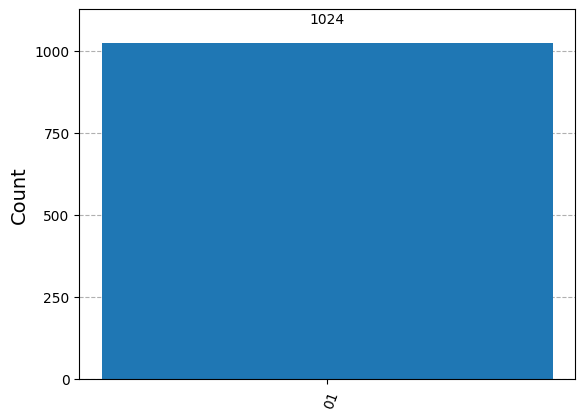

In [19]:
plot_histogram(counts)